# Monte Carlo Simulation of Random Walk Outcomes

A hands-on exploration of estimating probabilities through simulation.

## 1. Introduction

Some questions are hard to answer with a neat formula but easy to answer by **simulation**: just play the game many times and count. This notebook walks through one such question end to end.

## 2. Problem statement

A person starts on a staircase at **step 0** and throws a dice **100 times**. After all the throws, **what is the probability they have reached at least step 60?**

## 3. Random walk rules

- Dice **1-2**: step down 1 (never below 0)
- Dice **3-5**: step up 1
- Dice **6**: step up by a random 1-6
- Optional **fall risk**: a small chance each throw of slipping back to step 0

## 4. Why Monte Carlo simulation is useful

The clamp at zero, the big jumps on a six, and the optional fall risk make an exact formula awkward. Simulation sidesteps the maths: we run the experiment thousands of times and read the probability off the results. The more runs, the more reliable the estimate.

In [1]:
%matplotlib inline
import sys
from pathlib import Path

# Step up one folder so we can import the project's `src` package.
sys.path.append(str(Path.cwd().parent))

import numpy as np
import pandas as pd

from src import config
from src.simulation import simulate_single_walk, simulate_multiple_walks, get_endpoints
from src.analysis import summarize_endpoints, run_sensitivity_analysis
from src.visualization import plot_sample_walks, plot_endpoint_histogram

## 5. Simulating one random walk

In [2]:
single = simulate_single_walk(number_of_rolls=100, random_seed=123)
print("Length:", len(single), "| Start:", single[0], "| End:", single[-1])
single[:10]

Length: 101 | Start: 0 | End: 59


[0, 0, 1, 2, 1, 3, 2, 1, 2, 1]

## 6. Simulating many random walks

In [3]:
walks = simulate_multiple_walks(
    number_of_walks=config.DEFAULT_NUMBER_OF_WALKS,
    number_of_rolls=config.DEFAULT_NUMBER_OF_ROLLS,
    random_seed=config.DEFAULT_RANDOM_SEED,
)
print("Shape (walks, rolls+1):", walks.shape)

Shape (walks, rolls+1): (500, 101)


## 7. Visualizing sample walks

Each line is one possible journey up the staircase.

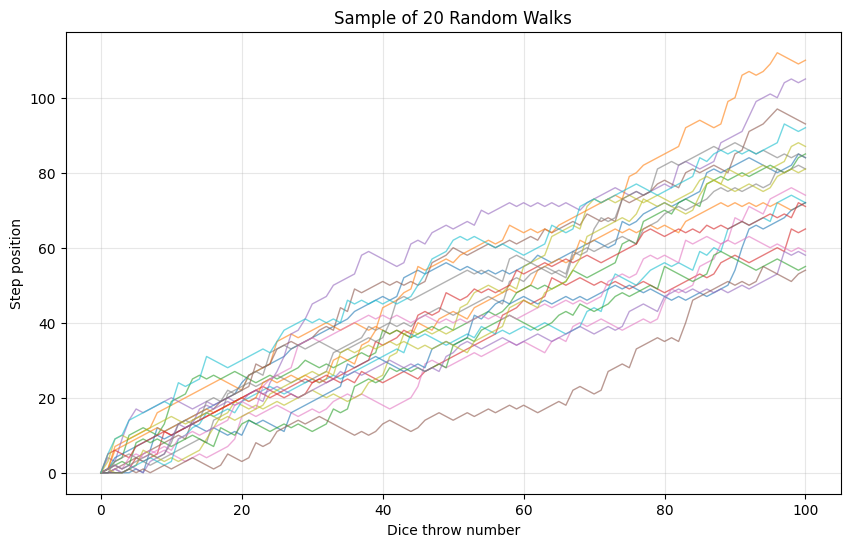

In [4]:
plot_sample_walks(walks, max_walks_to_plot=20);

## 8. Endpoint distribution

Where do the walks tend to finish? The red line marks our target.

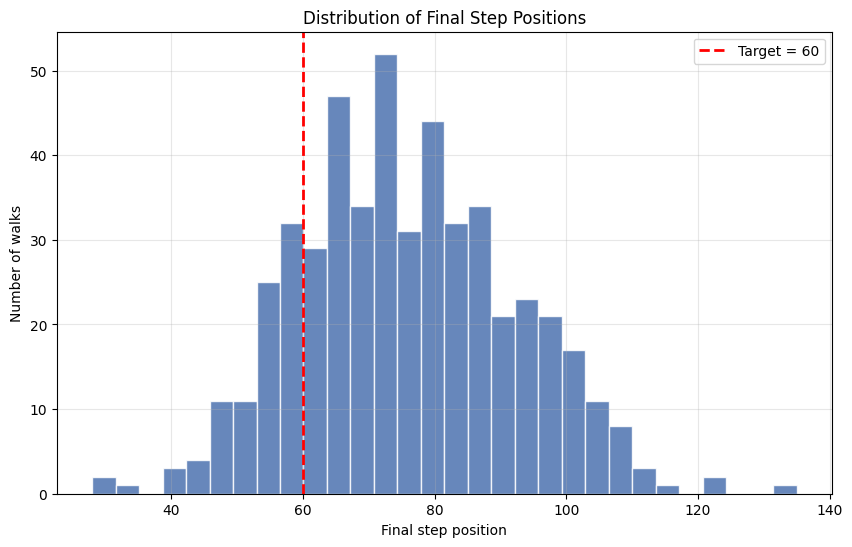

In [5]:
endpoints = get_endpoints(walks)
plot_endpoint_histogram(endpoints, target_step=config.DEFAULT_TARGET_STEP);

## 9. Calculating the probability of reaching 60 steps

In [6]:
summary = summarize_endpoints(endpoints, target_step=config.DEFAULT_TARGET_STEP)
summary

{'number_of_simulations': 500,
 'target_step': 60,
 'mean_endpoint': 75.78,
 'median_endpoint': 74.0,
 'min_endpoint': 28,
 'max_endpoint': 135,
 'standard_deviation': 16.36,
 'success_count': 422,
 'success_probability_percent': 84.4,
 'failure_probability_percent': 15.6,
 'percentile_5': 51.0,
 'percentile_25': 64.0,
 'percentile_75': 87.0,
 'percentile_95': 103.05}

## 10. Sensitivity analysis

Watch the probability estimate settle down as we use more simulations.

In [7]:
sensitivity = run_sensitivity_analysis(
    simulation_counts=config.DEFAULT_SENSITIVITY_COUNTS,
    number_of_rolls=config.DEFAULT_NUMBER_OF_ROLLS,
    target_step=config.DEFAULT_TARGET_STEP,
    random_seed=config.DEFAULT_RANDOM_SEED,
    fall_probability=0.0,
)
sensitivity

,simulation_count,success_probability_percent,mean_endpoint,standard_deviation
0,100,82.00,74.60,17.03
1,500,84.40,75.78,16.36
2,1000,84.30,76.09,16.50
3,5000,82.64,75.25,16.60
4,10000,83.61,75.62,16.53


## 11. Fall risk experiment

Now turn on a small fall risk and see how much harder the target becomes.

In [8]:
risky = simulate_multiple_walks(
    number_of_walks=config.DEFAULT_NUMBER_OF_WALKS,
    number_of_rolls=config.DEFAULT_NUMBER_OF_ROLLS,
    random_seed=config.DEFAULT_RANDOM_SEED,
    fall_probability=0.01,
)
risky_summary = summarize_endpoints(get_endpoints(risky), config.DEFAULT_TARGET_STEP)
print("No fall risk :", summary["success_probability_percent"], "%")
print("With fall risk:", risky_summary["success_probability_percent"], "%")

No fall risk : 84.4 %
With fall risk: 40.2 %


## 12. Final conclusion

Under the default dice rules the target is reached in the large majority of simulated walks. Adding even a small per-throw fall risk noticeably lowers that probability, because a single slip wipes out progress. Most importantly, the sensitivity analysis shows the estimate is stable once we run enough simulations - which is the whole promise of the Monte Carlo method.